**Car Data Analysis and Visualization using Pandas**

**1.PROBLEM STATEMENTS**

1.To develop a Python program using Pandas and NumPy for efficient data handling and processing.

2.To create and manipulate data structures like Series and DataFrames dynamically.

3.To analyze a real-world dataset (cars dataset)
and extract statistical insights.

4.To identify relationships between variables using correlation and visualize the results for better understanding.

**2.IMPORTS**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**3.RANGE SERIES**

In [46]:
def range_series(start=None, end=None):
    """
    Creates a pandas Series containing a range of integers.

    Args:
        start (int, optional): The starting integer of the range (inclusive). Defaults to 1.
        end (int, optional): The ending integer of the range (inclusive). Defaults to 10.

    Returns:
        pandas.Series: A Series containing integers from 'start' to 'end'.

    Raises:
        ValueError: If 'start' is greater than 'end'.
    """
    if start is None and end is None:
        start, end = 1, 10
    elif end is None:
        end = 10

    if start > end:
        raise ValueError("Start should be less than or equal to End")

    return pd.Series(range(start, end + 1))

**4.SUM OF NUMPY ARRAYS**

In [47]:
def sum_arrays(*arrays):
    """
    Sums multiple NumPy arrays element-wise.

    Args:
        *arrays: Variable number of NumPy arrays to be summed.

    Returns:
        numpy.ndarray: A new array containing the element-wise sum of the input arrays.

    Raises:
        ValueError: If no arrays are provided or if arrays have different dimensions.
    """
    if not arrays:
        raise ValueError("At least one array required")

    shape = arrays[0].shape

    for arr in arrays:
        if arr.shape != shape:
            raise ValueError("All arrays must have same dimensions")

    return np.sum(arrays, axis=0)

**5.CREATE DATAFRAME**

In [48]:
def create_dataframe(keys, values):
    """
    Creates a pandas DataFrame from a list of keys (column names) and a list of lists of values.

    Args:
        keys (list): A list of strings to be used as column names.
        values (list of lists): A list of lists, where each inner list contains the values for a column.
                                The order of inner lists should correspond to the order of keys.

    Returns:
        pandas.DataFrame: A new DataFrame created from the provided keys and values.

    Raises:
        ValueError: If the number of keys does not match the number of value lists,
                    or if the value lists have different lengths.
    """
    if len(keys) != len(values):
        raise ValueError("Keys and values length mismatch")

    length = len(values[0])
    for v in values:
        if len(v) != length:
            raise ValueError("All value lists must be same length")

    return pd.DataFrame(dict(zip(keys, values)))

**5.CONCAT DATAFRAMES**

In [49]:
def concat_dataframes(df1, df2):
    """
    Concatenates two pandas DataFrames vertically.

    Args:
        df1 (pandas.DataFrame): The first DataFrame.
        df2 (pandas.DataFrame): The second DataFrame.

    Returns:
        pandas.DataFrame: A new DataFrame resulting from the vertical concatenation of df1 and df2.
                          The index is reset to ensure a continuous integer index.
    """
    return pd.concat([df1, df2], ignore_index=True)

**6.LOAD DATASET + FULL ANALYSIS**

In [50]:
def load_and_analyze(file_path):
    """
    Loads a CSV file into a pandas DataFrame and performs basic initial analysis.

    Args:
        file_path (str): The path to the CSV file.

    Returns:
        pandas.DataFrame or None: The loaded DataFrame if successful, otherwise None.
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("File not found!")
        return None

    print("\n📊 BASIC INFO")
    print(df.info())

    print("\n📈 STATISTICS")
    print(df.describe())

    print("\n❌ MISSING VALUES")
    print(df.isnull().sum())

    return df

**7.CORRELATION ANALYSIS**

In [51]:
def get_max_correlated_column(df, column_name):
    """
    Finds the column that is most correlated (positively or negatively) with a specified column.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        column_name (str): The name of the target column.

    Returns:
        str: The name of the column with the highest absolute correlation to the target column.

    Raises:
        ValueError: If the specified column is not found in the DataFrame or is not numeric.
    """
    if column_name not in df.columns:
        raise ValueError("Column not found")

    corr = df.corr(numeric_only=True)

    if column_name not in corr:
        raise ValueError("Column must be numeric")

    # Get absolute correlations, drop the column itself, and find the max index
    return corr[column_name].drop(column_name).abs().idxmax()

**8.VISUALIZATION**

In [52]:
def plot_histograms(df):
    """
    Plots histograms for all numeric columns in a DataFrame to visualize their distributions.

    Args:
        df (pandas.DataFrame): The input DataFrame.
    """
    df.hist(figsize=(10, 8))
    plt.suptitle("Feature Distributions", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


def plot_correlation_heatmap(df):
    """
    Plots a correlation heatmap for all numeric columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
    """
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8)) # Set a larger figure size for better readability
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # Use seaborn for better aesthetics
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.columns)), corr.columns, rotation=0)
    plt.title("Correlation Heatmap", fontsize=16)
    plt.tight_layout() # Adjust layout
    plt.show()

**9.MAIN EXECUTION**


===== RANGE SERIES =====
0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int64
0     5
1     6
2     7
3     8
4     9
5    10
dtype: int64
0      5
1      6
2      7
3      8
4      9
5     10
6     11
7     12
8     13
9     14
10    15
dtype: int64

===== ARRAY SUM =====
[5 7 9]

===== DATAFRAME CREATION =====
  One Two
0   X   A
1   Y   B

===== CONCAT DATAFRAME =====
  One Two
0   X   A
1   Y   B
2   P   C
3   Q   D

===== LOAD DATASET =====

📊 BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     10 non-null     int64  
 1   cyl     10 non-null     int64  
 2   disp    10 non-null     int64  
 3   hp      10 non-null     int64  
 4   drat    10 non-null     float64
 5   wt      10 non-null     float64
dtypes: float64(2), int64(4)
memory usage: 612.0 bytes
None

📈 STATISTICS
             mpg        

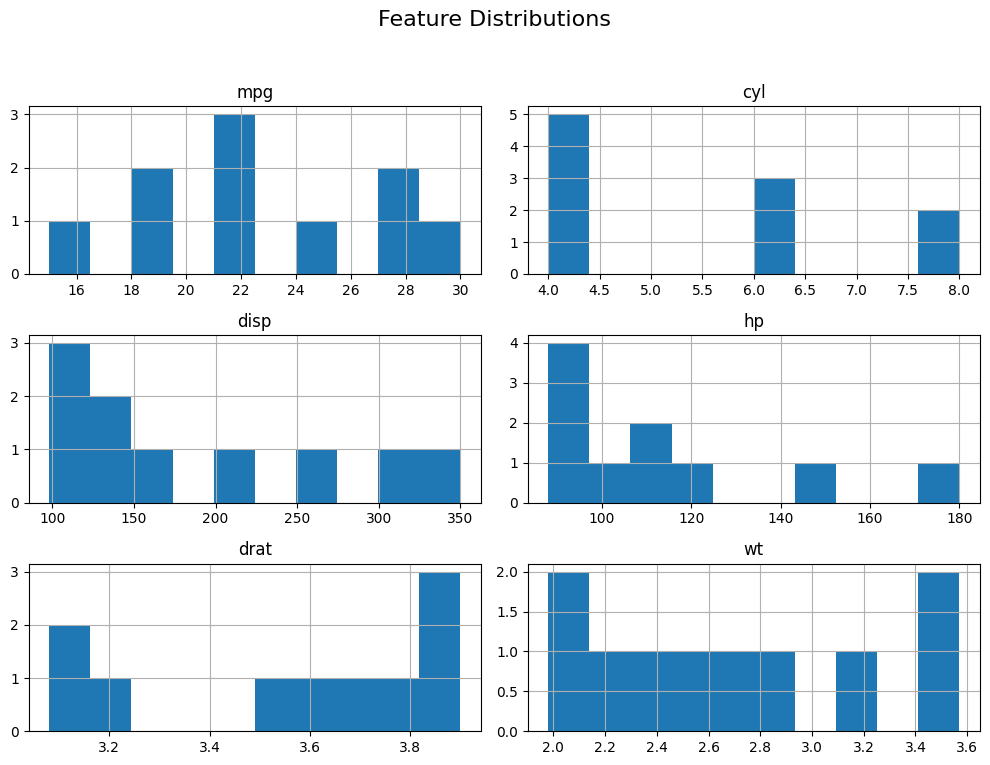

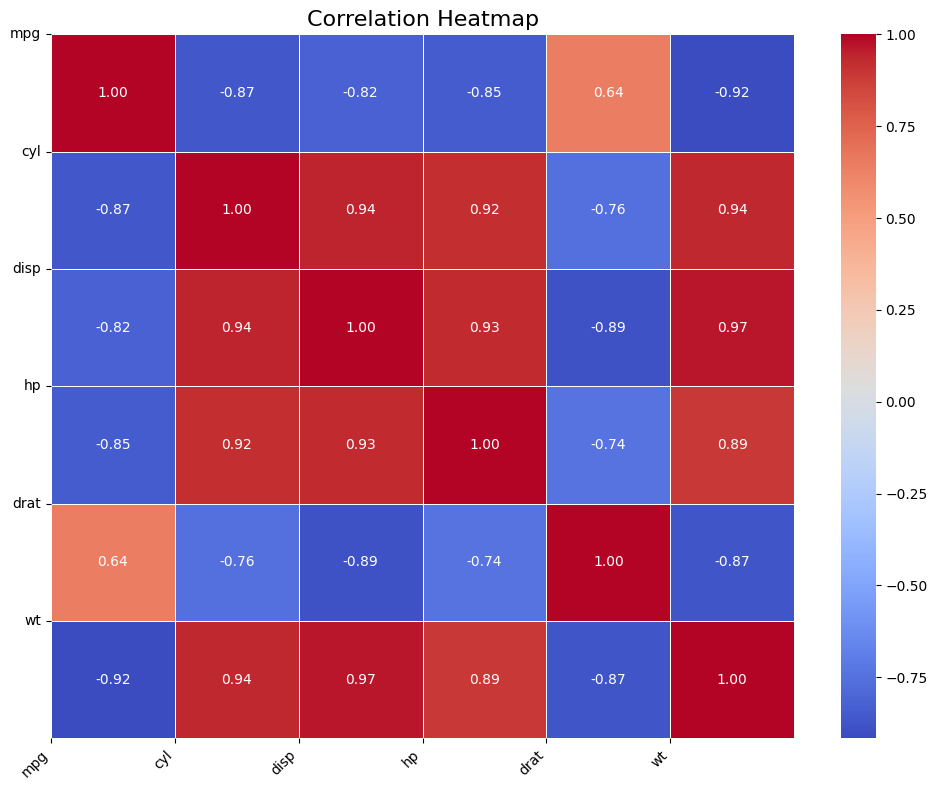

In [53]:
if __name__ == "__main__":

    print("\n===== RANGE SERIES =====")
    print(range_series())
    print(range_series(5))
    print(range_series(5, 15))

    print("\n===== ARRAY SUM =====")
    a = np.array([1, 2, 3])
    b = np.array([4, 5, 6])
    print(sum_arrays(a, b))

    print("\n===== DATAFRAME CREATION =====")
    df1 = create_dataframe(["One", "Two"], [["X", "Y"], ["A", "B"]])
    df2 = create_dataframe(["One", "Two"], [["P", "Q"], ["C", "D"]])
    print(df1)

    print("\n===== CONCAT DATAFRAME =====")
    combined = concat_dataframes(df1, df2)
    print(combined)

    print("\n===== LOAD DATASET =====")
    cars_df = load_and_analyze("cars.csv")

    if cars_df is not None:
        print("\n===== CORRELATION =====")
        print("Most correlated with mpg:",
              get_max_correlated_column(cars_df, 'mpg'))

        print("\n===== VISUALIZATION =====")
        plot_histograms(cars_df)
        plot_correlation_heatmap(cars_df)

**11. SCATTER PLOT VISUALIZATION**


===== SCATTER PLOTS ====


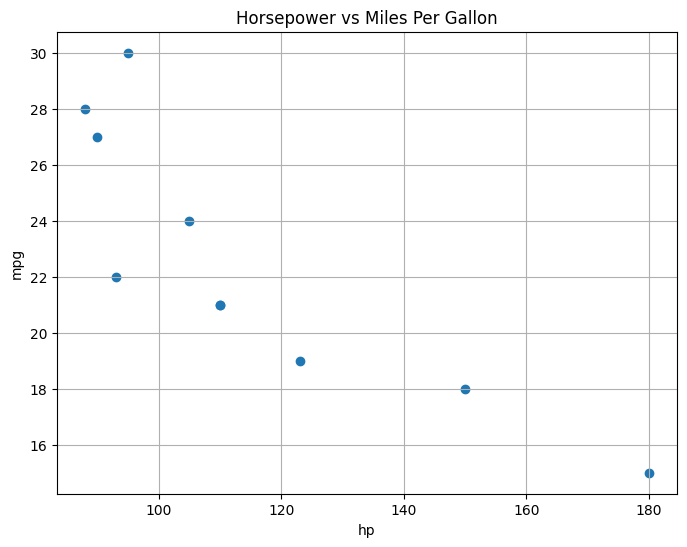

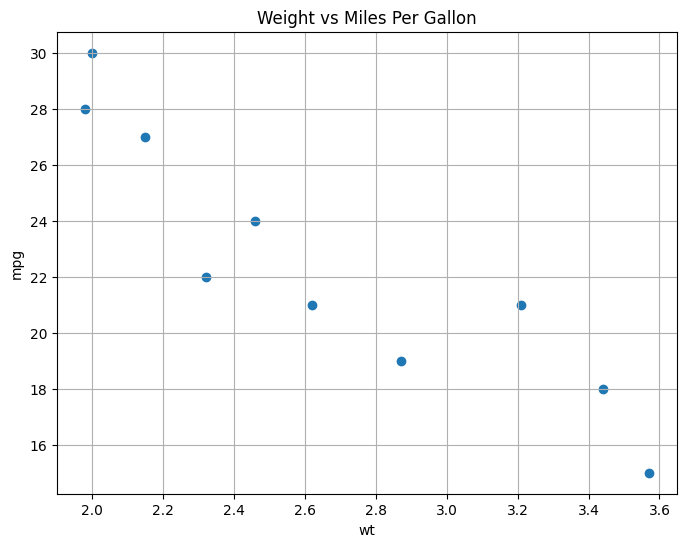

In [54]:
def plot_scatter(df, x_column, y_column, title=None):
    """
    Plots a scatter plot between two specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        x_column (str): The name of the column for the x-axis.
        y_column (str): The name of the column for the y-axis.
        title (str, optional): The title of the plot. Defaults to 'Scatter Plot'.

    Raises:
        ValueError: If specified columns are not found in the DataFrame.
    """
    if x_column not in df.columns or y_column not in df.columns:
        raise ValueError(f"Both '{x_column}' and '{y_column}' must be in the DataFrame columns.")

    plt.figure(figsize=(8, 6))
    plt.scatter(df[x_column], df[y_column])
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(title if title else f'Scatter Plot of {x_column} vs {y_column}')
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== SCATTER PLOTS ====")
        try:
            plot_scatter(cars_df, 'hp', 'mpg', 'Horsepower vs Miles Per Gallon')
            plot_scatter(cars_df, 'wt', 'mpg', 'Weight vs Miles Per Gallon')
        except ValueError as e:
            print(f"Error creating scatter plot: {e}")

**11. SCATTER PLOT VISUALIZATION**


===== SCATTER PLOTS ====


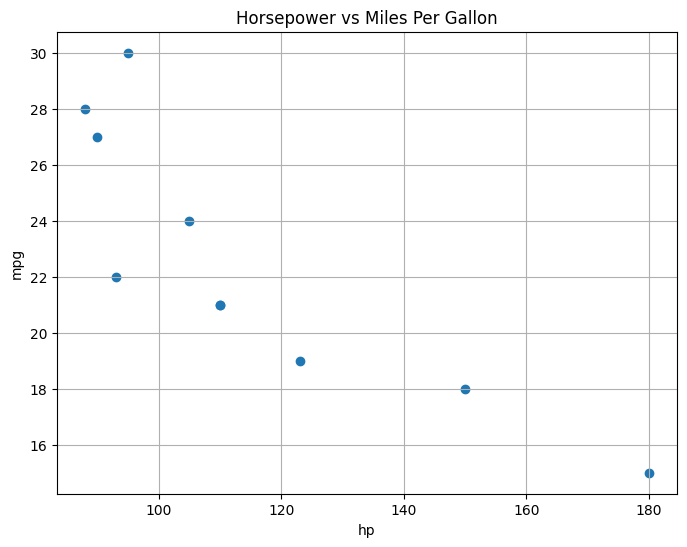

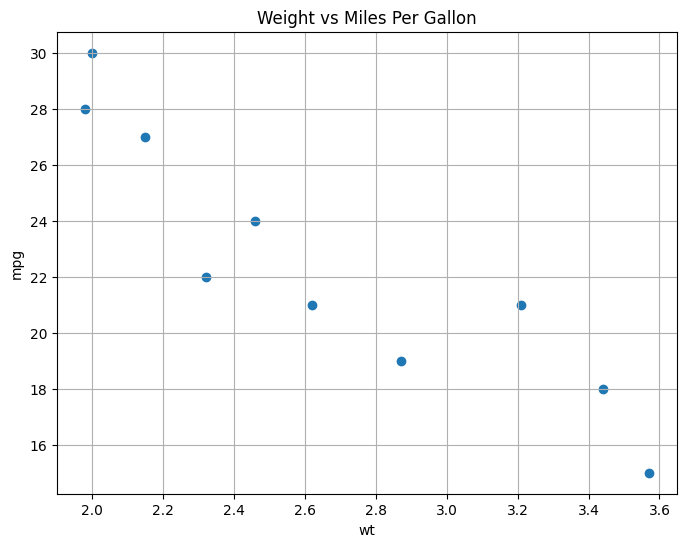

In [55]:
def plot_scatter(df, x_column, y_column, title=None):
    """
    Plots a scatter plot between two specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        x_column (str): The name of the column for the x-axis.
        y_column (str): The name of the column for the y-axis.
        title (str, optional): The title of the plot. Defaults to 'Scatter Plot'.

    Raises:
        ValueError: If specified columns are not found in the DataFrame.
    """
    if x_column not in df.columns or y_column not in df.columns:
        raise ValueError(f"Both '{x_column}' and '{y_column}' must be in the DataFrame columns.")

    plt.figure(figsize=(8, 6))
    plt.scatter(df[x_column], df[y_column])
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(title if title else f'Scatter Plot of {x_column} vs {y_column}')
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== SCATTER PLOTS ====")
        try:
            plot_scatter(cars_df, 'hp', 'mpg', 'Horsepower vs Miles Per Gallon')
            plot_scatter(cars_df, 'wt', 'mpg', 'Weight vs Miles Per Gallon')
        except ValueError as e:
            print(f"Error creating scatter plot: {e}")

**12. DATA CLEANING: HANDLING MISSING VALUES**

In [56]:
def drop_missing_values(df):
    """
    Drops rows with any missing values from the DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.

    Returns:
        pandas.DataFrame: A new DataFrame with rows containing missing values dropped.
    """
    original_rows = df.shape[0]
    df_cleaned = df.dropna()
    rows_dropped = original_rows - df_cleaned.shape[0]
    print(f"Dropped {rows_dropped} rows with missing values.")
    return df_cleaned


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== HANDLING MISSING VALUES ====")
        # Introduce some missing values for demonstration if none exist
        temp_df = cars_df.copy()
        if temp_df.isnull().sum().sum() == 0:
            # Example: set a couple of values to NaN for demonstration
            temp_df.loc[0, 'mpg'] = np.nan
            temp_df.loc[3, 'hp'] = np.nan
            print("\nIntroduced missing values for demonstration:")
            print(temp_df.head())

        cleaned_cars_df = drop_missing_values(temp_df)
        print("\nDataFrame after dropping missing values:")
        print(cleaned_cars_df.info())
        print(cleaned_cars_df.describe())


===== HANDLING MISSING VALUES ====

Introduced missing values for demonstration:
    mpg  cyl  disp     hp  drat    wt
0   NaN    6   160  110.0  3.90  2.62
1  22.0    4   108   93.0  3.85  2.32
2  18.0    8   318  150.0  3.20  3.44
3  21.0    6   258    NaN  3.08  3.21
4  30.0    4   120   95.0  3.70  2.00
Dropped 2 rows with missing values.

DataFrame after dropping missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 1 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     8 non-null      float64
 1   cyl     8 non-null      int64  
 2   disp    8 non-null      int64  
 3   hp      8 non-null      float64
 4   drat    8 non-null      float64
 5   wt      8 non-null      float64
dtypes: float64(4), int64(2)
memory usage: 448.0 bytes
None
             mpg       cyl        disp          hp      drat        wt
count   8.000000  8.000000    8.000000    8.000000  8.000000  8.000000
mean   22.875000  5

**13. DATA PREPROCESSING: FEATURE SCALING**

In [57]:
from sklearn.preprocessing import StandardScaler

def scale_features(df, numeric_cols):
    """
    Applies StandardScaler to specified numeric columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        numeric_cols (list): A list of column names to be scaled.

    Returns:
        pandas.DataFrame: A new DataFrame with the specified columns scaled.
        sklearn.preprocessing.StandardScaler: The fitted StandardScaler object.

    Raises:
        ValueError: If any specified column is not found or is not numeric.
    """
    df_scaled = df.copy()
    for col in numeric_cols:
        if col not in df_scaled.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame.")
        if not pd.api.types.is_numeric_dtype(df_scaled[col]):
            raise ValueError(f"Column '{col}' is not numeric and cannot be scaled.")

    scaler = StandardScaler()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
    print(f"Scaled columns: {numeric_cols}")
    return df_scaled, scaler


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== FEATURE SCALING ====")
        # Select numeric columns for scaling (excluding non-numeric if any)
        numeric_cols_to_scale = cars_df.select_dtypes(include=np.number).columns.tolist()

        try:
            scaled_cars_df, scaler_obj = scale_features(cars_df.copy(), numeric_cols_to_scale)
            print("\nOriginal DataFrame (first 5 rows):\n", cars_df.head())
            print("\nScaled DataFrame (first 5 rows):\n", scaled_cars_df.head())
            print("\nDescriptive statistics of scaled DataFrame:\n", scaled_cars_df.describe())
        except ValueError as e:
            print(f"Error during feature scaling: {e}")


===== FEATURE SCALING ====
Scaled columns: ['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt']

Original DataFrame (first 5 rows):
    mpg  cyl  disp   hp  drat    wt
0   21    6   160  110  3.90  2.62
1   22    4   108   93  3.85  2.32
2   18    8   318  150  3.20  3.44
3   21    6   258  110  3.08  3.21
4   30    4   120   95  3.70  2.00

Scaled DataFrame (first 5 rows):
         mpg       cyl      disp        hp      drat        wt
0 -0.333333  0.384111 -0.350876 -0.156561  1.070301 -0.075454
1 -0.111111 -0.896258 -0.963142 -0.761455  0.905640 -0.614413
2 -1.000000  1.664479  1.509473  1.266719 -1.234963  1.397699
3 -0.333333  0.384111  0.803011 -0.156561 -1.630151  0.984498
4  1.666667 -0.896258 -0.821850 -0.690291  0.411654 -1.189302

Descriptive statistics of scaled DataFrame:
                 mpg           cyl          disp            hp          drat  \
count  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01   
mean   2.220446e-17 -2.664535e-16 -1.332268e-16 -2.2204

**11. SCATTER PLOT VISUALIZATION**


===== SCATTER PLOTS ====


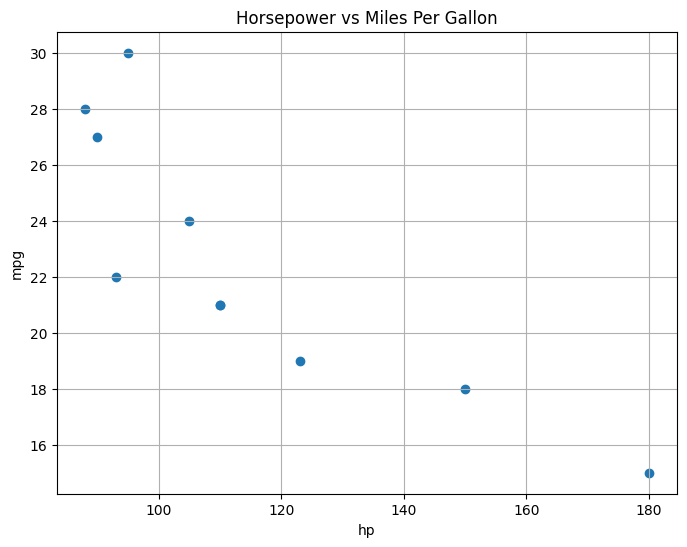

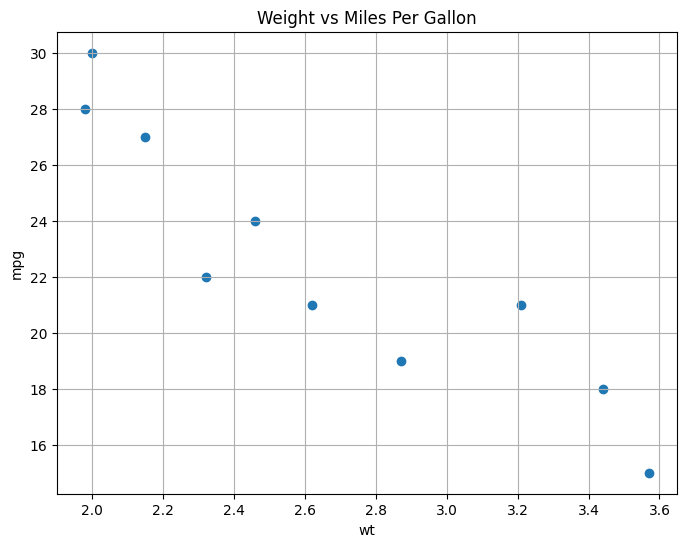

In [58]:
def plot_scatter(df, x_column, y_column, title=None):
    """
    Plots a scatter plot between two specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        x_column (str): The name of the column for the x-axis.
        y_column (str): The name of the column for the y-axis.
        title (str, optional): The title of the plot. Defaults to 'Scatter Plot'.

    Raises:
        ValueError: If specified columns are not found in the DataFrame.
    """
    if x_column not in df.columns or y_column not in df.columns:
        raise ValueError(f"Both '{x_column}' and '{y_column}' must be in the DataFrame columns.")

    plt.figure(figsize=(8, 6))
    plt.scatter(df[x_column], df[y_column])
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(title if title else f'Scatter Plot of {x_column} vs {y_column}')
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== SCATTER PLOTS ====")
        try:
            plot_scatter(cars_df, 'hp', 'mpg', 'Horsepower vs Miles Per Gallon')
            plot_scatter(cars_df, 'wt', 'mpg', 'Weight vs Miles Per Gallon')
        except ValueError as e:
            print(f"Error creating scatter plot: {e}")

**12. DATA CLEANING: HANDLING MISSING VALUES**

In [59]:
def drop_missing_values(df):
    """
    Drops rows with any missing values from the DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.

    Returns:
        pandas.DataFrame: A new DataFrame with rows containing missing values dropped.
    """
    original_rows = df.shape[0]
    df_cleaned = df.dropna()
    rows_dropped = original_rows - df_cleaned.shape[0]
    print(f"Dropped {rows_dropped} rows with missing values.")
    return df_cleaned


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== HANDLING MISSING VALUES ====")
        # Introduce some missing values for demonstration if none exist
        temp_df = cars_df.copy()
        if temp_df.isnull().sum().sum() == 0:
            # Example: set a couple of values to NaN for demonstration
            temp_df.loc[0, 'mpg'] = np.nan
            temp_df.loc[3, 'hp'] = np.nan
            print("\nIntroduced missing values for demonstration:")
            print(temp_df.head())

        cleaned_cars_df = drop_missing_values(temp_df)
        print("\nDataFrame after dropping missing values:")
        print(cleaned_cars_df.info())
        print(cleaned_cars_df.describe())


===== HANDLING MISSING VALUES ====

Introduced missing values for demonstration:
    mpg  cyl  disp     hp  drat    wt
0   NaN    6   160  110.0  3.90  2.62
1  22.0    4   108   93.0  3.85  2.32
2  18.0    8   318  150.0  3.20  3.44
3  21.0    6   258    NaN  3.08  3.21
4  30.0    4   120   95.0  3.70  2.00
Dropped 2 rows with missing values.

DataFrame after dropping missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 1 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     8 non-null      float64
 1   cyl     8 non-null      int64  
 2   disp    8 non-null      int64  
 3   hp      8 non-null      float64
 4   drat    8 non-null      float64
 5   wt      8 non-null      float64
dtypes: float64(4), int64(2)
memory usage: 448.0 bytes
None
             mpg       cyl        disp          hp      drat        wt
count   8.000000  8.000000    8.000000    8.000000  8.000000  8.000000
mean   22.875000  5

**13. DATA PREPROCESSING: FEATURE SCALING**

In [60]:
from sklearn.preprocessing import StandardScaler

def scale_features(df, numeric_cols):
    """
    Applies StandardScaler to specified numeric columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        numeric_cols (list): A list of column names to be scaled.

    Returns:
        pandas.DataFrame: A new DataFrame with the specified columns scaled.
        sklearn.preprocessing.StandardScaler: The fitted StandardScaler object.

    Raises:
        ValueError: If any specified column is not found or is not numeric.
    """
    df_scaled = df.copy()
    for col in numeric_cols:
        if col not in df_scaled.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame.")
        if not pd.api.types.is_numeric_dtype(df_scaled[col]):
            raise ValueError(f"Column '{col}' is not numeric and cannot be scaled.")

    scaler = StandardScaler()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
    print(f"Scaled columns: {numeric_cols}")
    return df_scaled, scaler


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== FEATURE SCALING ====")
        # Select numeric columns for scaling (excluding non-numeric if any)
        numeric_cols_to_scale = cars_df.select_dtypes(include=np.number).columns.tolist()

        try:
            scaled_cars_df, scaler_obj = scale_features(cars_df.copy(), numeric_cols_to_scale)
            print("\nOriginal DataFrame (first 5 rows):\n", cars_df.head())
            print("\nScaled DataFrame (first 5 rows):\n", scaled_cars_df.head())
            print("\nDescriptive statistics of scaled DataFrame:\n", scaled_cars_df.describe())
        except ValueError as e:
            print(f"Error during feature scaling: {e}")


===== FEATURE SCALING ====
Scaled columns: ['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt']

Original DataFrame (first 5 rows):
    mpg  cyl  disp   hp  drat    wt
0   21    6   160  110  3.90  2.62
1   22    4   108   93  3.85  2.32
2   18    8   318  150  3.20  3.44
3   21    6   258  110  3.08  3.21
4   30    4   120   95  3.70  2.00

Scaled DataFrame (first 5 rows):
         mpg       cyl      disp        hp      drat        wt
0 -0.333333  0.384111 -0.350876 -0.156561  1.070301 -0.075454
1 -0.111111 -0.896258 -0.963142 -0.761455  0.905640 -0.614413
2 -1.000000  1.664479  1.509473  1.266719 -1.234963  1.397699
3 -0.333333  0.384111  0.803011 -0.156561 -1.630151  0.984498
4  1.666667 -0.896258 -0.821850 -0.690291  0.411654 -1.189302

Descriptive statistics of scaled DataFrame:
                 mpg           cyl          disp            hp          drat  \
count  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01  1.000000e+01   
mean   2.220446e-17 -2.664535e-16 -1.332268e-16 -2.2204

**10. AVERAGE CALCULATION**

In [61]:
def calculate_column_average(df, column_name):
    """
    Calculates the average of a specified numeric column in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        column_name (str): The name of the column for which to calculate the average.

    Returns:
        float: The average value of the specified column.

    Raises:
        ValueError: If the column is not found or is not numeric.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame.")
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        raise ValueError(f"Column '{column_name}' is not numeric.")
    return df[column_name].mean()


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== AVERAGE CALCULATION ====")
        try:
            avg_mpg = calculate_column_average(cars_df, 'mpg')
            print(f"Average MPG: {avg_mpg:.2f}")
            avg_hp = calculate_column_average(cars_df, 'hp')
            print(f"Average HP: {avg_hp:.2f}")
        except ValueError as e:
            print(f"Error calculating average: {e}")



===== AVERAGE CALCULATION ====
Average MPG: 22.50
Average HP: 114.40


**10. AVERAGE CALCULATION**

In [62]:
def calculate_column_average(df, column_name):
    """
    Calculates the average of a specified numeric column in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        column_name (str): The name of the column for which to calculate the average.

    Returns:
        float: The average value of the specified column.

    Raises:
        ValueError: If the column is not found or is not numeric.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame.")
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        raise ValueError(f"Column '{column_name}' is not numeric.")
    return df[column_name].mean()


if __name__ == "__main__":
    if 'cars_df' in locals() and cars_df is not None:
        print("\n===== AVERAGE CALCULATION ====")
        try:
            avg_mpg = calculate_column_average(cars_df, 'mpg')
            print(f"Average MPG: {avg_mpg:.2f}")
            avg_hp = calculate_column_average(cars_df, 'hp')
            print(f"Average HP: {avg_hp:.2f}")
        except ValueError as e:
            print(f"Error calculating average: {e}")



===== AVERAGE CALCULATION ====
Average MPG: 22.50
Average HP: 114.40
